# IMPORT LIBRARIES

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import os

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [3]:
train_data = train_datagen.flow_from_directory(
    'train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    shuffle=True
)

Found 8000 images belonging to 2 classes.


In [4]:
val_data = val_datagen.flow_from_directory(
    'val',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [5]:
test_data = test_datagen.flow_from_directory(
    'test',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 800 images belonging to 2 classes.


In [6]:
print("Class Labels:", train_data.class_indices)

Class Labels: {'NORMAL': 0, 'PNEUMONIA': 1}


# CNN

In [7]:
model = Sequential([
    Conv2D(32, (3,3),
           activation = 'relu',
           input_shape = (224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(1, activation = 'sigmoid'),
])

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,263,809 (73.49 MB)

 Trainable params: 19,263,809 (73.49 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
os.makedirs("models", exist_ok=True)

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [12]:
checkpoint = ModelCheckpoint(
    "models/pneumonia_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20


In [ ]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9137 - loss: 0.2360
Test Accuracy: 91.37%


In [ ]:
model.save("pneumonia_model.keras")
print("Model saved successfully")

Model saved successfully


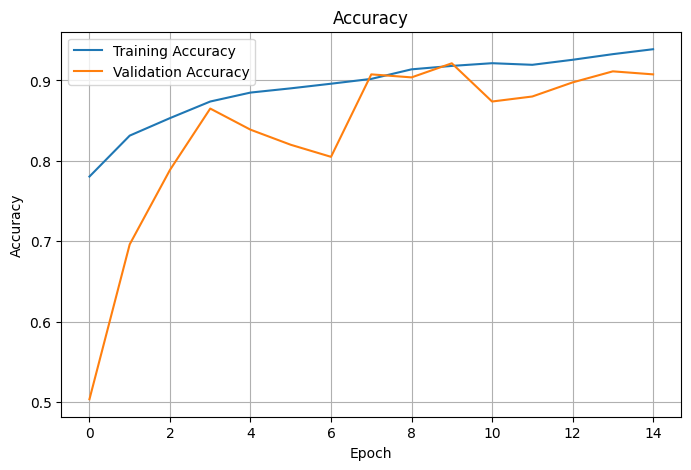

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

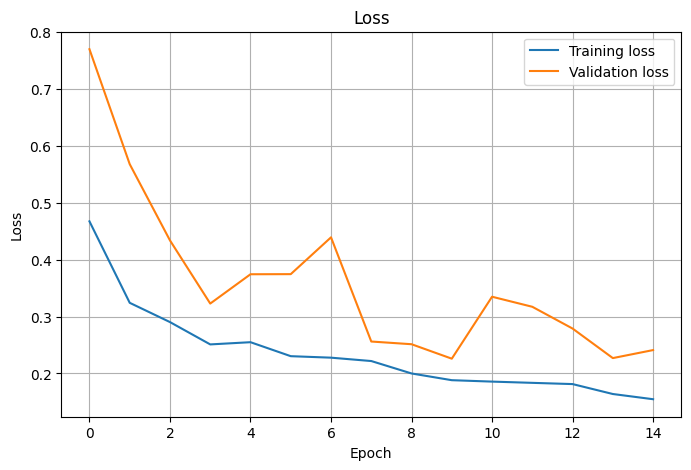

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
img = image.load_img("train\NORMAL\augmented_555.jpg", target_size=(224,224))
img_arr = image.img_to_array(img)

img_arr = np.expand_dims(img_arr, axis=0)
img_arr = img_arr/255.0
predict = model.predict(img_arr)
print(predict)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 5-6: malformed \N character escape (4223790853.py, line 2)

In [ ]:
classes = ['NORMAL', 'PNEUMONIA']
pred = np.argmax(predict, axis=1)[0]
print('Prediction :',classes[pred])

Prediction : Healthy
